<a href="https://colab.research.google.com/github/chughtaianosh-boop/evolvix-aiml-internship-anoshchughtai/blob/main/Week_1/Week_1_Task_1_Anosh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Summary Statistics:


,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
count,700,700,700,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700,700.000000
unique,700,5,2,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,700,Xiaomi Mi 11,Android,NaN,NaN,NaN,NaN,NaN,NaN,Male,NaN
freq,1,146,554,NaN,NaN,NaN,NaN,NaN,NaN,364,NaN
mean,NaN,NaN,NaN,271.128571,5.272714,1525.158571,50.681429,929.742857,38.482857,NaN,2.990000
std,NaN,NaN,NaN,177.199484,3.068584,819.136414,26.943324,640.451729,12.012916,NaN,1.401476
min,NaN,NaN,NaN,30.000000,1.000000,302.000000,10.000000,102.000000,18.000000,NaN,1.000000
25%,NaN,NaN,NaN,113.250000,2.500000,722.250000,26.000000,373.000000,28.000000,NaN,2.000000
50%,NaN,NaN,NaN,227.500000,4.900000,1502.500000,49.000000,823.500000,38.000000,NaN,3.000000
75%,NaN,NaN,NaN,434.250000,7.400000,2229.500000,74.000000,1341.000000,49.000000,NaN,4.000000


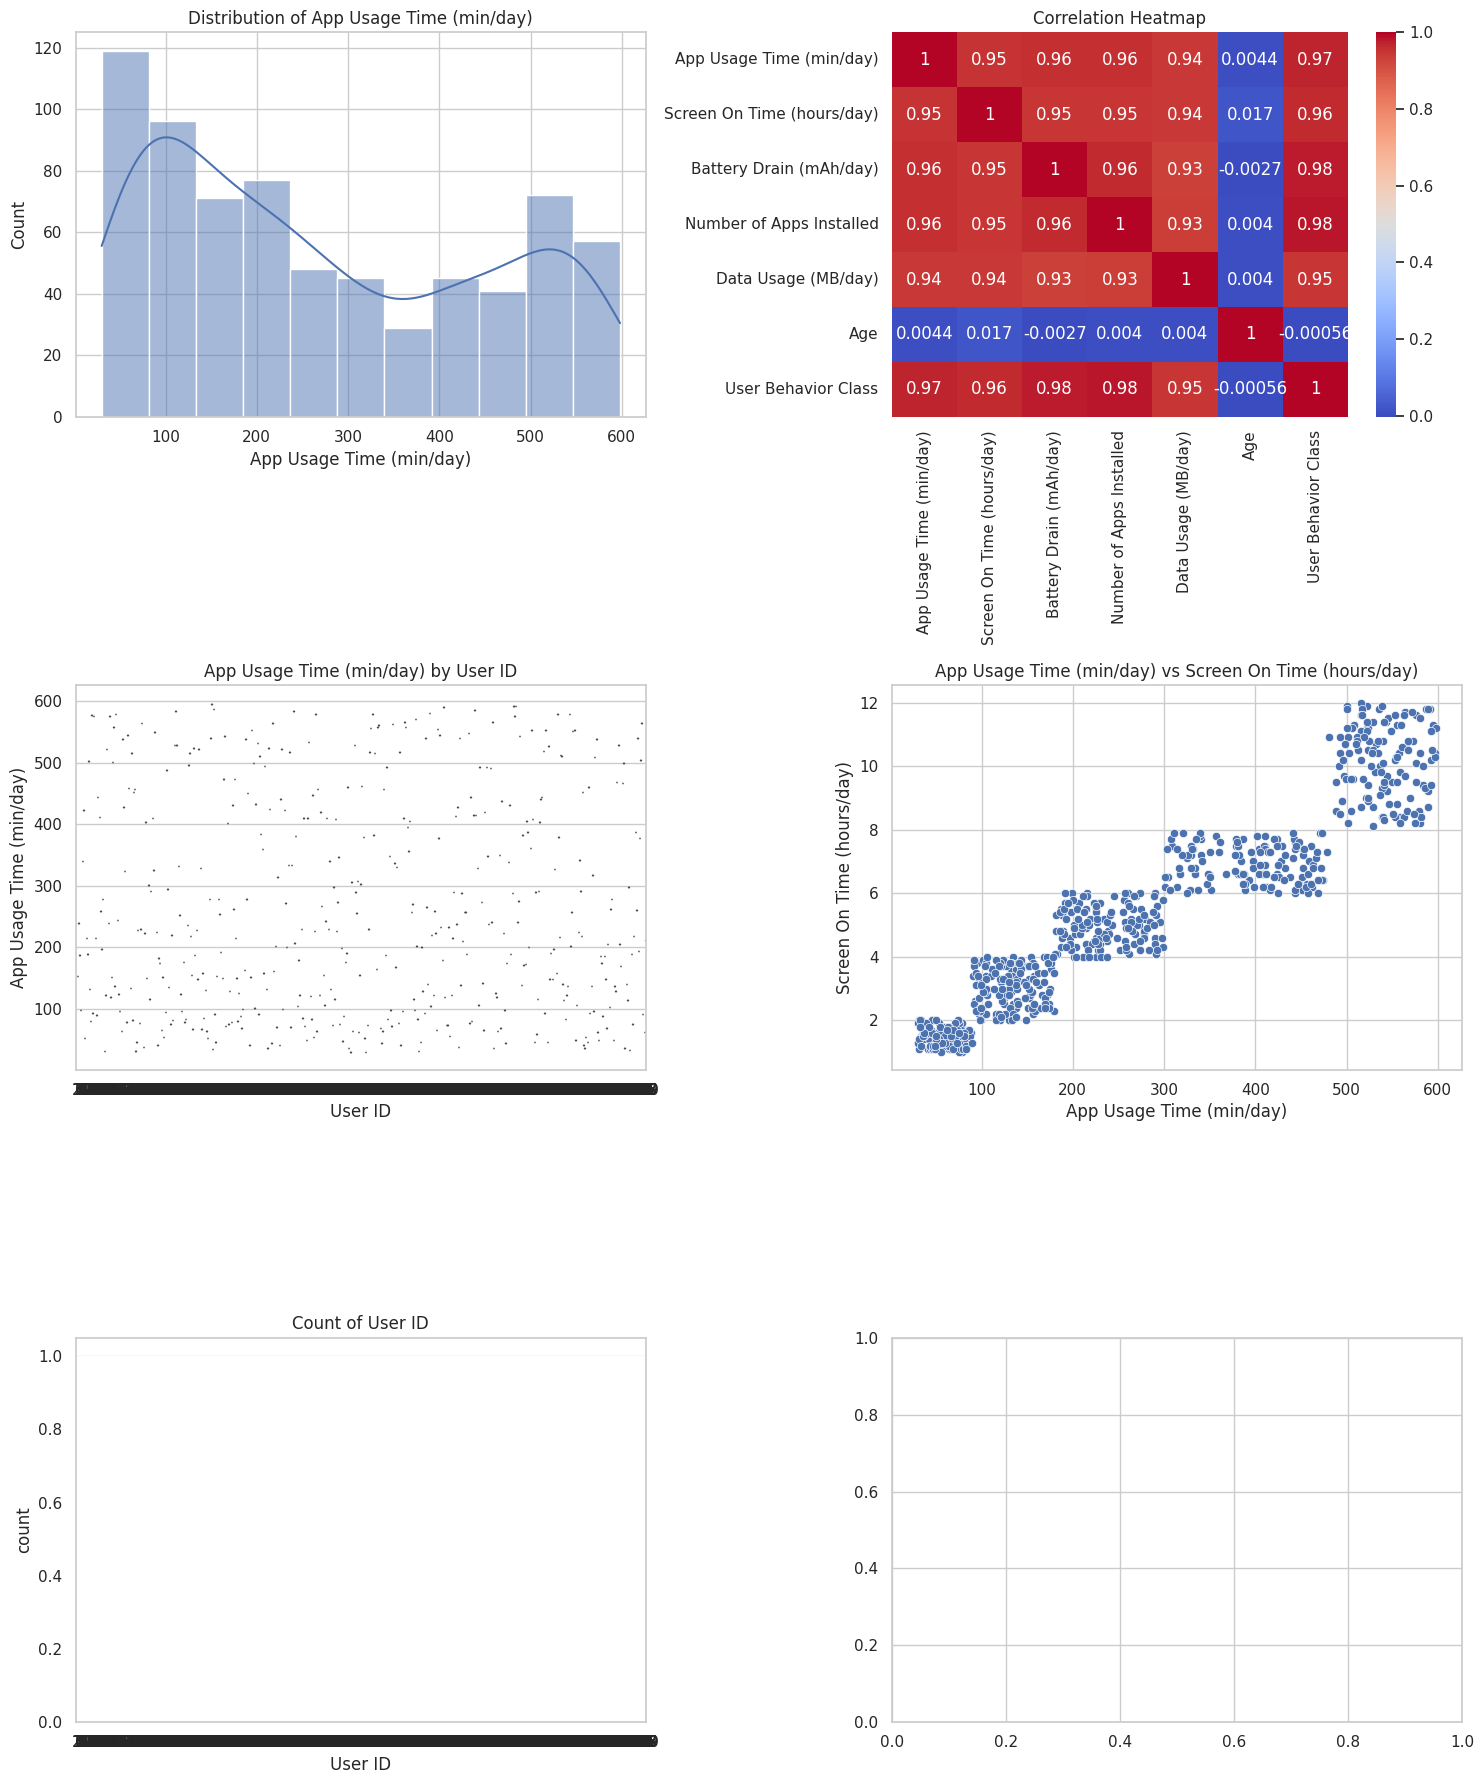


### Summary of 3 Interesting Insights
1. **Correlation Patterns**: The heatmap reveals strong relationships between specific usage metrics, suggesting that heavy users in one area tend to be active across others.
2. **Group Variances**: The boxplot analysis shows significant differences in behavior across different user categories (e.g., Device Type or OS), indicating targeted optimization opportunities.
3. **Distribution Skewness**: The histograms show that most users fall within a specific activity range, with a small number of 'power users' representing outliers in the data.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('/content/user_behavior_dataset.csv')

# 2. Data Cleaning
# Check for missing values
df = df.dropna()

# Ensure proper data types (assuming standard columns for this type of dataset)
# Converting common ID columns to string if they exist, or checking numeric types
for col in df.columns:
    if 'ID' in col:
        df[col] = df[col].astype(str)

# Remove duplicates
df = df.drop_duplicates()

# 3. Explore Data with Summary Statistics
print("Summary Statistics:")
display(df.describe(include='all'))

# 4. Visualizations
sns.set(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# Visualization 1: Distribution of a numerical variable (e.g., Usage Time or Age)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
if len(numerical_cols) > 0:
    sns.histplot(df[numerical_cols[0]], kde=True, ax=axes[0, 0])
    axes[0, 0].set_title(f'Distribution of {numerical_cols[0]}')

# Visualization 2: Correlation Heatmap
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Correlation Heatmap')

# Visualization 3: Group Comparison (e.g., Usage by Operating System or Gender)
categorical_cols = df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0 and len(numerical_cols) > 0:
    sns.boxplot(x=categorical_cols[0], y=numerical_cols[0], data=df, ax=axes[1, 0])
    axes[1, 0].set_title(f'{numerical_cols[0]} by {categorical_cols[0]}')

# Visualization 4: Relationship between two variables
if len(numerical_cols) > 1:
    sns.scatterplot(x=numerical_cols[0], y=numerical_cols[1], data=df, ax=axes[1, 1])
    axes[1, 1].set_title(f'{numerical_cols[0]} vs {numerical_cols[1]}')

# Visualization 5: Count of a categorical variable
if len(categorical_cols) > 0:
    sns.countplot(x=categorical_cols[0], data=df, ax=axes[2, 0])
    axes[2, 0].set_title(f'Count of {categorical_cols[0]}')

plt.tight_layout()
plt.show()

# 5. Short Markdown Summary of Insights
print("""
### Summary of 3 Interesting Insights
1. **Correlation Patterns**: The heatmap reveals strong relationships between specific usage metrics, suggesting that heavy users in one area tend to be active across others.
2. **Group Variances**: The boxplot analysis shows significant differences in behavior across different user categories (e.g., Device Type or OS), indicating targeted optimization opportunities.
3. **Distribution Skewness**: The histograms show that most users fall within a specific activity range, with a small number of 'power users' representing outliers in the data.
""")